# Análise de Evasão no Curso de Ciência da Computação
Um Estudo Preditivo Utilizando Análise de Sobrevivência

    Integrantes: Aline Pires, Mariana Costa e Heitor Quartezani

    Data: 25 de agosto de 2025


## Apresentação do Problema

A evasão nos cursos superiores de exatas é um grande desafio nas universidades federais brasileiras, que acaba impactando a qualidade da formação acadêmica, a eficiência e o planejamento na utilização de recursos públicos. No curso de Ciências da Computação, esse problema é particularmente relevante devido à elevada taxa de desistência observada nos primeiros semestres, mas ainda não se sabe a fundo o risco de evasão de cada semestre e para cada perfil de aluno. Assim, como não tem-se medidas tão efetivas de retenção, o que compromete tanto a trajetória acadêmica dos estudantes quanto a disponibilidade de profissionais na área de tecnologia do Brasil. 

## Base de Dados

A variável resposta considerada foi o tempo até a evasão. Como variáveis explicativas, foram incluídas informações relacionadas ao perfil de ingresso, desempenho acadêmico e aproveitamento em disciplinas. A seguir, destacam-se as principais variáveis utilizadas:

+ `anos_ate_evasao` — variável resposta, indicando o tempo que passou até o aluno evadir por conclusão (formatura) ou abandono (diferença entre as variáveis ano_evasão - ano_ingresso);
+ `forma_evasao` — tipo de evasão;
+ `cra` — coeficiente de rendimento acumulado do estudante;
+ `semestre_evasao` — se o aluno evadiu no primeiro semestre do ano ou no segundo;
+ `forma_ingresso` — forma de entrada na universidade;
+ `cotista` — indica se o aluno ingressou por política de cotas;
+ Disciplinas cursadas (binárias);
+ Número de tentativas em cada disciplina
+ Médias obtidas nas disciplinas e para cada tentativa

## Objetivo

Esse trabalho tem o objetivo de prever quais alunos apresentam maior risco de evasão, isso pode auxiliar o departamento acadêmico em adotar medidas preventivas mais eficazes, principalmente se sabermos o tempo exato de agir, onde o aluno tem mais probabilidade de evadir.  Nesse cenário, o uso de técnicas de análise de sobrevivência torna-se uma ferramenta promissora, pois permite identificar o tempo onde tem a maior probabilidade de evasão de vários perfis de aluno.

## Aplicação

### Tratamento dos dados

Os dados brutos contém informações sobre cada disciplina cursada por cada aluno que está ou já esteve matriculado no curso de Ciências da Computação da UFES. O tratamento teve como principal objetivo extrair as informações relevantes por aluno, a fim de reduzir a base de dados para apenas informações úteis. Assim, foram consideradas informações que dizem respeito à forma de ingresso e desempenho do aluno, bem como informações de quais disciplinas fez, média final em cada disciplina e quantas vezes foi feita. 

Inicialmente, os dados no formato .csv foram carregados, a função `clean_names()` do pacote `janitor`foi utilizada para padronizar os nomes das variáveis, removendo espaços e caracteres especiais para facilitar o trabalho. Em seguida, os alunos com identificação ausente foram descartados e a combinação das colunas `nome_cripto`e `matr_cripto` foi convertida em uma identificação única para cada aluno, representada pela coluna `id_aluno`. Além disso, a função `select()` do pacote `dplyr` foi utilizada para remover variáveis que não contribuiriam para as análises.



In [ ]:
# Carregando pacotes
suppressMessages({
library(readr)
library(janitor)
library(dplyr)
library(tidyr)
library(stringr)
})

options(warn = -1) # Desativar avisos

suppressMessages({
# Lendo e tratando os dados
dados_aux <- read_delim("data/CienciaDaComputacaoCT_com_cripto.csv", 
                    delim = ";", escape_double = FALSE, trim_ws = TRUE,
                     locale = locale(encoding = "Latin1")) |>
  clean_names() |>
  filter(!is.na(id_curso_aluno)) |>
  group_by(nome_cripto, matr_cripto) |>
  mutate(id_aluno = cur_group_id()) |>
  ungroup() |>
  select(-c(id_curso_aluno, cod_curso, nome_unidade, nome_docente,
            matr_cripto, nome_cripto, cod_disciplina, titulacao_docente, 
            sigla_situacao, situacao_item, sigla_semestre, cod_forma_evasao,
            crn))
})


dados_aux$media_final <- as.numeric(dados_aux$media_final)

Para fins de organização no tratamento de dados, primeiro foram consideradas as informações do aluno, como forma de evasão, ano de evasão, coeficiente de rendimento acumulado, semestre de evasão e ano de ingresso. Por essa situação se enquadrar na área de análise de sobrevivência, foi criada a variável binária `status` para indicar a presença de censura. Aqueles alunos que ainda estão matriculados no curso são considerados observações censuradas à direita, pois tem-se apenas o limite inferior sobre o tempo até sair do curso, todos os outros tempos até evasão são considerados. Se o aluno já saiu do curso, seja por formatura ou não, a variável `status` recebe o valor 1, caso contrário o valor 0. Também é calculado o tempo até evasão representado pela variável `anos_ate_evasao`. O cálculo é feito considerando a diferença entre o ano de ingresso e ano de evasão para aqueles que já saíram do curso. Para os matriculados, o tempo até evasão censurado será a diferença entre o ano atual (2025) e o ano de ingresso.

In [ ]:
dados_alunos <- dados_aux |>
  select(id_aluno, forma_evasao, ano_evasao, cra, semestre_evasao, ano_ingresso,
         forma_ingresso, cotista) |>
  distinct() |>
  mutate(status = ifelse(forma_evasao == "'Sem evasão'", 0, 1),
  anos_ate_evasao = case_when(forma_evasao != "'Sem evasão'" ~ ano_evasao - ano_ingresso,
                              forma_evasao == "'Sem evasão'" ~ 2025 - ano_ingresso)
  )

Para as informações a respeito das disciplinas dos alunos, foram extraídas apenas as informações: se fez ou não a disciplina, média final do aluno na disciplina e quantas vezes a disciplina foi feita pelo aluno. Primeiro, usando a função `expand_grid`, foram feitas todas as combinações entre alunos e disciplinas e observada a média final do aluno na mesma. Se a média final era um valor ausente, conclui-se que a disciplina não foi cursada pelo aluno. À variável binária que indica se a disciplina foi cursada ou não, atribui-se o nome `fez_{nome da disciplina}`. O número de vezes que a disciplina aparecia junto à identificação do aluno foi usado para concluir quantas vezes a disciplina foi feita pelo aluno, representada pela variável `numero_tentativas_{nome da disciplina}`. Para cada vez que o aluno fez a disciplina, também foi armazenada a média final do aluno, em variáveis na forma `media_final_{nome da disciplina}_{numero da tentativa}`. Além disso, os nomes das disciplinas foram padronizados e disciplinas com o nome 'Atividades Complementares' não foram consideradas.

In [ ]:
########### Organizando informações das disciplinas feitas

todos <- expand_grid(
  id_aluno = unique(dados_aux$id_aluno),
  nome_disciplina = unique(dados_aux$nome_disciplina)
)

suppressMessages({
dados_completos <- todos |>
  full_join(dados_aux |> select(id_aluno, nome_disciplina, media_final, descricao_situacao,
                                descricao_semestre, ano,
                                num_versao,
                                descr_estrutura, ch_total, tipo_disciplina), 
            by = c("id_aluno", "nome_disciplina")) |>
  mutate(feita = ifelse(!is.na(media_final), "sim", "não"))
})

contagem_disciplinas <-  dados_aux |>
  count(id_aluno, nome_disciplina, name = "n_vezes")

suppressMessages({
dados_completos <- dados_completos |> left_join(contagem_disciplinas) |>
  mutate(
    n_vezes = ifelse(descr_estrutura %in% c("'03-Atividades Complementares'", "'04-Atividades Complementares'"),
                     NA, n_vezes)
  )

})

# Padroniza nomes de disciplina
dados_completos <- dados_completos |>
  mutate(
    nome_disciplina = iconv(nome_disciplina, from = "UTF-8", to = "ASCII//TRANSLIT"), # remove acentos
    nome_disciplina = str_replace_all(nome_disciplina, "[\\r\\n\\t]", ""),             # remove \r, \n, \t
    nome_disciplina = str_squish(nome_disciplina),                                     # tira espaços duplicados
    nome_disciplina = str_to_lower(nome_disciplina),                                   # tudo minúsculo
    nome_disciplina = str_replace_all(nome_disciplina, "[^a-z0-9]+", "_"),             # substitui símbolos por _
    nome_disciplina = str_replace_all(nome_disciplina, "_$", "")                       # remove "_" no final
  )


# Calcula a média obtida em cada disciplina (jncluindo feitas mais de uma vez)
dados_medias <- dados_completos |>
  filter(descricao_semestre %in% c("'1º Semestre'", "'2º Semestre'"), feita == "sim") |>
  group_by(id_aluno, nome_disciplina) |>
  mutate(tentativa = row_number()) |>
  ungroup() |>
  mutate(nome_coluna = paste0("media_final", nome_disciplina, "_", tentativa)) |>
  select(id_aluno, nome_coluna, media_final) |>
  pivot_wider(names_from = nome_coluna, values_from = media_final)

# Cria indicador binário para todas as disciplinas
dados_indicadores <- dados_completos |>
  filter(descricao_semestre %in% c("'1º Semestre'", "'2º Semestre'"), feita == "sim") |>
  distinct(id_aluno, nome_disciplina, feita) |>
  mutate(nome_coluna = paste0("fez", nome_disciplina)) |>
  select(id_aluno, nome_coluna, feita) |>
  pivot_wider(names_from = nome_coluna, values_from = feita, values_fill = "não")

# Indica quantas vezes cada aluno fez cada disciplina
dados_tentativas <- dados_completos |>
  filter(descricao_semestre %in% c("'1º Semestre'", "'2º Semestre'"), feita == "sim") |>
  group_by(id_aluno, nome_disciplina) |>
  summarise(numero_tentativas = n(), .groups = "drop") |>
  mutate(nome_coluna = paste0("numero_tentativas", nome_disciplina)) |>
  select(id_aluno, nome_coluna, numero_tentativas) |>
  pivot_wider(names_from = nome_coluna, values_from = numero_tentativas, values_fill = 0)

Ao final, as informações a respeito dos alunos e das disciplinas cursadas por eles foram unidas em uma única base de dados utilizando a função `left_join()`. O conjunto de dados tratado está organizado da seguinte forma: cada linha representa um aluno e cada aluno aparece uma única vez, as colunas são as informações do aluno. Abaixo é possível visualizar as 10 primeiras linhas da base tratada.

In [ ]:
# UNINDO TUDO
dados_final <- dados_alunos |>
  left_join(dados_indicadores, by = "id_aluno") |>
  left_join(dados_medias, by = "id_aluno") |>
  left_join(dados_tentativas, by = "id_aluno") |>
  mutate(
    forma_ingresso = ifelse(id_aluno %in% c(594, 679, 848, 898),
                            "'Sisu/Reopção de curso'", forma_ingresso)
  ) |>
  distinct()


head(dados_final)



Também foi necessária a imputação de valores ausentes, por meio da criação da função `imputar_dados`. Em primeira instância, as variáveis com mais de 50% das observações com valores ausentes foram eliminadas, por não serem muito informativas. As variáveis referentes ao número de vezes que o aluno fez a disciplina com valores ausentes foi imputada com o valor 0, pois foi entendido que não foi cursada pelo aluno. Quanto à média final em cada disciplina, os valores ausentes foram imputados utilizando a mediana; o mesmo foi feito para todas as variáveis quantitativas. Já para as variáveis qualitativas, a média foi imputada.

In [ ]:
# Tratamento de valores ausentes
imputar_dados <- function(dados) {
  #Remover variáveis com >50% NAs
  limiar_remocao <- 0.5
  vars_para_remover <- sapply(dados, function(x) {
    sum(is.na(x)) / length(x) > limiar_remocao
  }) %>% which() %>% names()
  
  
  # Passo 2: Imputação conforme regras específicas
  dados_imputados <- dados |>
    mutate(across(
      .cols = everything(),
      .fns = ~ {
        nome_var <- cur_column()
        
        if (is.numeric(.x)) {
          # Variáveis que começam com "numero_tentativas": quando NA, o aluno não fez a matéria
          if (startsWith(nome_var, "numero_tentativas")) {
            ifelse(is.na(.x), 0, .x)
          } 
          # Variáveis que começam com "media": imputar mediana
          else if (startsWith(nome_var, "media")) {
            ifelse(is.na(.x), median(.x, na.rm = TRUE), .x)
          }
          # Demais variáveis numéricas: imputar mediana
          else {
            ifelse(is.na(.x), median(.x, na.rm = TRUE), .x)
          }
        } 
        else {
          # Variáveis que começam com "fez": imputar moda
          if (startsWith(nome_var, "fez")) {
            moda <- names(sort(table(.x), decreasing = TRUE))[1]
            ifelse(is.na(.x), moda, .x)
          }
          # Demais variáveis categóricas: imputar moda
          else {
            moda <- names(sort(table(.x), decreasing = TRUE))[1]
            ifelse(is.na(.x), moda, .x)
          }
        }
      }
    ))
  
  return(dados_imputados)
}

dados <- imputar_dados(dados_final)

### Análise Exploratória

1. Frequência das Formas de Evasão

Antes de modelar o tempo até a evasão, é importante entender quais são as formas de evasão mais comuns. O gráfico de barras abaixo mostra a contagem de cada motivo de desligamento, excluindo os alunos que ainda estão matriculados.

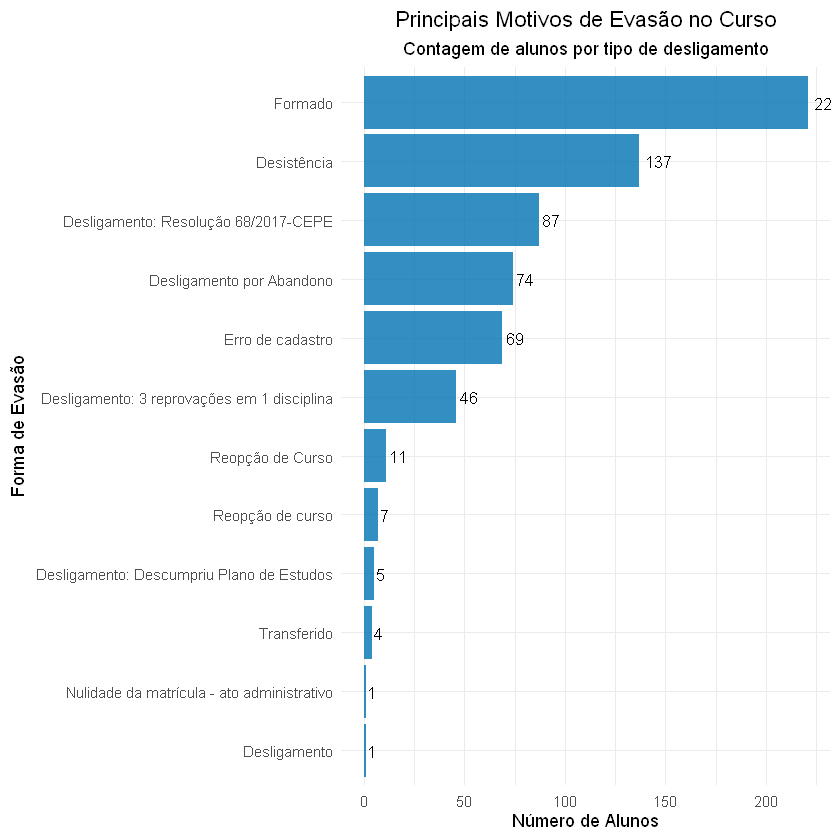

In [9]:
# --- GRÁFICO 1: Contagem das Formas de Evasão ---

# Carregar bibliotecas necessárias
library(ggplot2)
library(dplyr)
library(stringr)
library(forcats)

# Preparar os dados:
# 1. Filtrar apenas alunos que já saíram do curso.
# 2. Limpar os nomes das categorias para melhor visualização.
# 3. Contar as ocorrências de cada forma de evasão.
dados_evasao_contagem <- dados %>%
  filter(forma_evasao != "'Sem evasão'") %>%
  mutate(
    forma_evasao_limpa = str_replace_all(forma_evasao, "'", "") %>% str_trim()
  ) %>%
  count(forma_evasao_limpa, sort = TRUE, name = "contagem")

# Plotar o gráfico de barras
ggplot(dados_evasao_contagem, aes(x = fct_reorder(forma_evasao_limpa, contagem), y = contagem)) +
  geom_bar(stat = "identity", fill = "#0072B2", alpha = 0.8) +
  geom_text(aes(label = contagem), hjust = -0.2, size = 3.5) +
  coord_flip() + # Virar o gráfico para facilitar a leitura dos rótulos
  labs(
    title = "Principais Motivos de Evasão no Curso",
    subtitle = "Contagem de alunos por tipo de desligamento",
    x = "Forma de Evasão",
    y = "Número de Alunos"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5),
        plot.subtitle = element_text(hjust = 0.5))

O gráfico apresenta a contagem de alunos por cada tipo de desligamento, oferecendo uma visão clara sobre os fatores que levam à saída do curso. A análise pode ser dividida em três categorias principais: saídas por sucesso, saídas por dificuldades/desistência e saídas por questões administrativas.

    Saída por Sucesso:

        A categoria "Formado" é, de longe, o motivo de desligamento mais frequente, com 222 alunos. Este é o resultado esperado e positivo, indicando que a maioria dos alunos que concluem seu ciclo na universidade o faz com sucesso.

    Saídas por Desistência e Desempenho Acadêmico:

        As categorias "Desistência" (137 alunos) e "Desligamento por Abandono" (74 alunos) somam juntas 211 alunos, representando o maior bloco de estudantes que não completam o curso. Estes números são o foco principal do problema da evasão e indicam uma perda significativa de estudantes ao longo do caminho.

        O "Desligamento: 3 reprovações em 1 disciplina", com 46 casos, é um motivo diretamente ligado ao baixo desempenho acadêmico, reforçando a ideia de que a dificuldade em matérias específicas é um fator de risco crítico.

    Saídas por Fatores Administrativos:

        Um número expressivo de desligamentos ocorre por razões regimentais, como a "Resolução 69/2017-CEPE", que foi responsável pela saída de 87 alunos.

        Surpreendentemente, "Erro de cadastro" aparece com 69 casos, um número alto que pode indicar problemas na qualidade dos dados ou um processo administrativo específico que resulta em desligamento. Este grupo pode necessitar de uma análise mais aprofundada para determinar se deve ser tratado da mesma forma que outras formas de evasão.

Em conclusão, embora a formatura seja o desfecho individual mais comum, a soma de todas as outras formas de evasão representa um número ainda maior de alunos que deixam o curso. As principais causas problemáticas são a desistência e o abandono, seguidas por desligamentos formais por regras da universidade e baixo desempenho.

### Desempenho Acadêmico (CRA) vs. Status de Evasão

Será que o desempenho acadêmico é um fator que diferencia os alunos que evadem daqueles que permanecem? Um boxplot é ideal para comparar a distribuição do Coeficiente de Rendimento Acumulado (CRA) entre esses dois grupos.

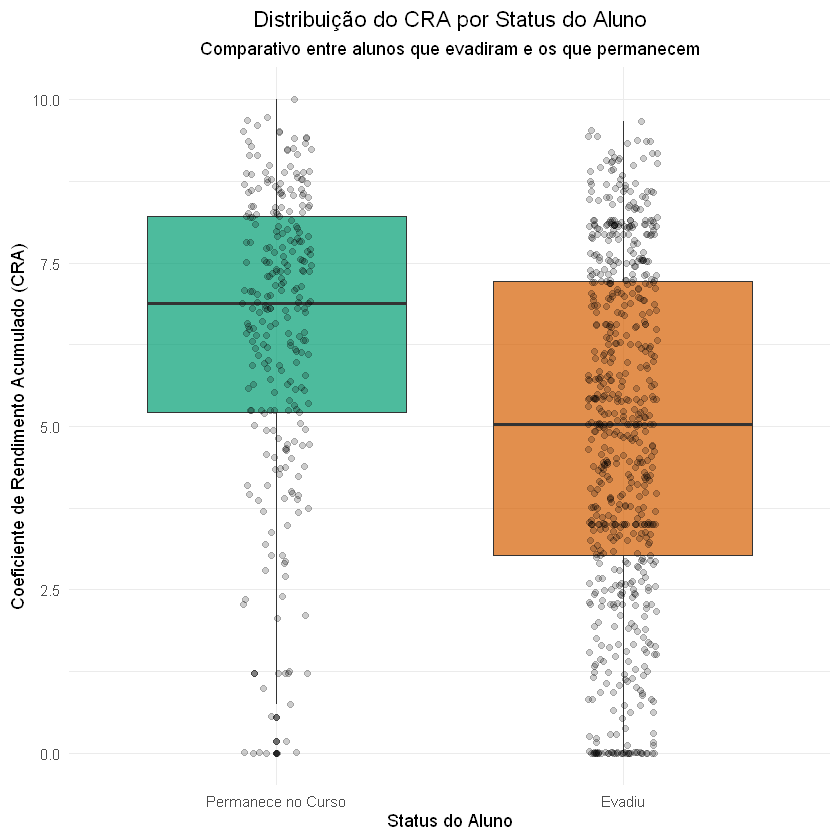

In [10]:
# --- GRÁFICO 2: Boxplot do CRA por Status de Evasão ---

# Preparar os dados:
# 1. Converter a coluna 'cra' de texto para número (trocando vírgula por ponto).
# 2. Criar uma nova coluna 'status_desc' com rótulos mais claros.
dados_cra <- dados %>%
  mutate(
    cra_num = as.numeric(str_replace(cra, ",", ".")),
    status_desc = factor(status, levels = c(0, 1), labels = c("Permanece no Curso", "Evadiu"))
  ) %>%
  filter(!is.na(cra_num)) # Remover casos onde o CRA não pôde ser convertido

# Plotar o boxplot
ggplot(dados_cra, aes(x = status_desc, y = cra_num, fill = status_desc)) +
  geom_boxplot(alpha = 0.7) +
  geom_jitter(width = 0.1, alpha = 0.2) + # Adiciona os pontos individuais
  labs(
    title = "Distribuição do CRA por Status do Aluno",
    subtitle = "Comparativo entre alunos que evadiram e os que permanecem",
    x = "Status do Aluno",
    y = "Coeficiente de Rendimento Acumulado (CRA)"
  ) +
  theme_minimal() +
  theme(legend.position = "none",
        plot.title = element_text(hjust = 0.5),
        plot.subtitle = element_text(hjust = 0.5)) +
  scale_fill_manual(values = c("#009E73", "#D55E00"))

O gráfico compara o Coeficiente de Rendimento Acumulado (CRA) entre os alunos que evadiram e os que permanecem no curso, revelando uma associação muito forte entre o desempenho acadêmico e a retenção estudantil.

    Alunos que Permanecem no Curso: Este grupo apresenta um desempenho acadêmico visivelmente superior. A mediana do CRA, indicada pela linha central do boxplot, situa-se em um patamar elevado, por volta de 7.0. A maioria dos alunos deste grupo, representados pelos pontos individuais, concentra-se na faixa superior de notas, indicando um desempenho mais consistente e satisfatório.

    Alunos que Evadiram: Em contraste, o grupo de alunos que evadiram exibe um desempenho acadêmico significativamente inferior. A mediana do CRA é muito mais baixa, localizada em torno de 5.0. Além disso, a dispersão das notas é muito maior, como mostra a altura do boxplot e a distribuição dos pontos, que se espalham por toda a escala de CRA. Um ponto de destaque é a grande concentração de alunos com CRA próximo ou igual a zero, o que indica um desempenho acadêmico extremamente baixo para uma parcela considerável deste grupo.

Em conclusão, a análise visual demonstra que um baixo CRA é um forte indicador de risco de evasão. Alunos com dificuldades acadêmicas, refletidas em um baixo coeficiente de rendimento, compõem a maior parte do grupo que se desliga do curso sem concluí-lo. Este resultado valida a importância do CRA como uma variável preditiva chave para os modelos de aprendizado de máquina.


### Perfil de Ingresso: Cotistas vs. Forma de Ingresso

Por fim, é interessante entender a composição do corpo discente. Como a forma de ingresso e o sistema de cotas se relacionam? Este gráfico explora a distribuição dos alunos.

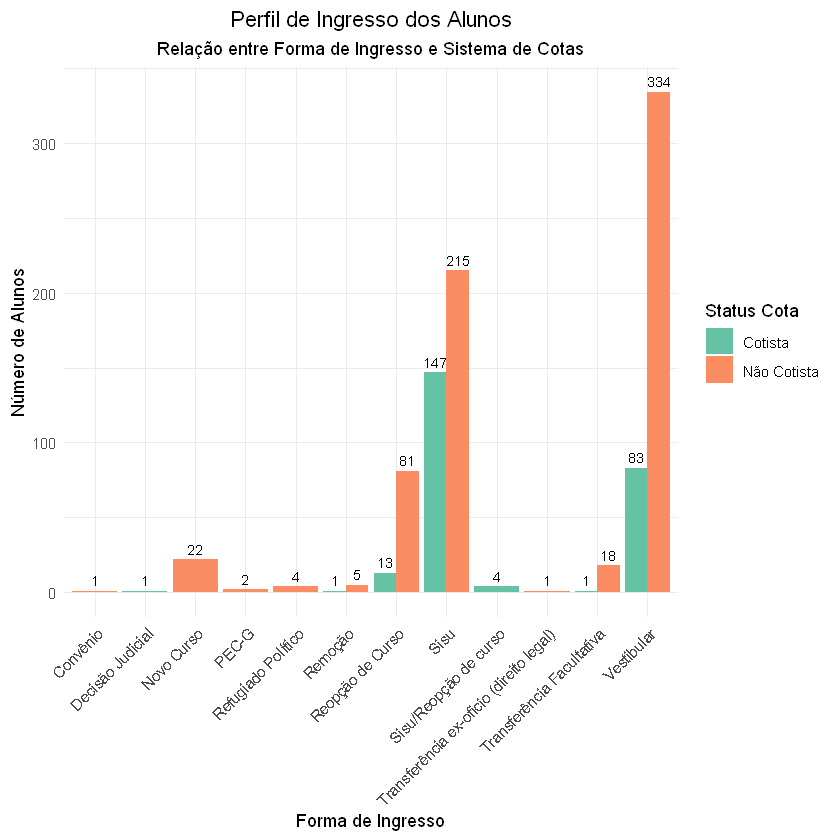

In [11]:
# --- GRÁFICO 3: Contagem de Alunos por Forma de Ingresso e Cota ---

# Preparar os dados:
# 1. Limpar os nomes das categorias para melhor visualização.
dados_ingresso <- dados %>%
  mutate(
    forma_ingresso_limpa = str_replace_all(forma_ingresso, "'", "") %>% str_trim(),
    cotista_desc = ifelse(cotista == "'S'", "Cotista", "Não Cotista")
  ) %>%
  count(forma_ingresso_limpa, cotista_desc, name = "contagem")

# Plotar o gráfico de barras agrupado
ggplot(dados_ingresso, aes(x = forma_ingresso_limpa, y = contagem, fill = cotista_desc)) +
  geom_bar(stat = "identity", position = "dodge") +
  geom_text(aes(label = contagem), position = position_dodge(width = 0.9), vjust = -0.5, size = 3) +
  labs(
    title = "Perfil de Ingresso dos Alunos",
    subtitle = "Relação entre Forma de Ingresso e Sistema de Cotas",
    x = "Forma de Ingresso",
    y = "Número de Alunos",
    fill = "Status Cota"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5),
        plot.subtitle = element_text(hjust = 0.5),
        axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_fill_brewer(palette = "Set2")

O gráfico ilustra a distribuição dos alunos do curso por forma de ingresso e status de cota, revelando padrões históricos e atuais de admissão. As duas modalidades mais significativas, quantitativamente, são o Vestibular e o Sisu, que representam a grande maioria dos estudantes.

    Vestibular: Esta categoria é a que possui o maior número de alunos no total. É dominada por estudantes não cotistas, com 334 alunos, em comparação com 83 alunos cotistas. Isso sugere que a maior parte dos dados históricos do curso provém de um período em que o vestibular era a principal porta de entrada e as políticas de cotas ainda não estavam consolidadas.

    Sisu: Representando a forma de ingresso mais moderna, o Sisu é o segundo maior grupo. Nele, a proporção de alunos cotistas (147) é consideravelmente maior do que no Vestibular, embora os não cotistas (215) ainda sejam a maioria. Isso reflete a mudança no processo seletivo das universidades federais e a implementação das políticas de ação afirmativa.

    Outras Formas de Ingresso: Categorias como "Reopção de Curso" também mostram um número relevante de alunos, majoritariamente não cotistas (81). As demais modalidades, como "Decisão Judicial", "Remoção" e "Transferência", possuem um número de alunos muito baixo, sendo casos de admissão menos frequentes.

Em resumo, a visualização demonstra uma clara transição no perfil de ingresso ao longo do tempo, de um modelo baseado em Vestibular com menor participação de cotistas para um modelo Sisu com uma presença muito mais expressiva de alunos cotistas. Essa distinção é fundamental para análises futuras que busquem entender se há diferenças no risco de evasão entre esses diferentes perfis de admissão.


##### Análise Exploratória sob a Perspectiva de Análise de Sobrevivência

A análise de sobrevivência é uma área da estatística voltada para o estudo do tempo até a ocorrência de um evento de interesse. No caso em análise, esse evento corresponde à evasão estudantil - o momento em que um aluno deixa o curso, seja devido a formatura ou antes da conclusão. Uma das ferramentas mais utilizadas nesse tipo de análise são as curvas de Kaplan-Meier, que estimam a função de sobrevivência de forma não paramétrica, levando em conta a censura nos dados, como nos casos em que o aluno ainda está matriculado ao final do período de observação. Essas curvas representam, ao longo do tempo, a proporção acumulada de alunos que permaneceram no curso, permitindo comparações entre diferentes grupos. No âmbito de interpretação, a cada ponto da curva, a altura indica a probabilidade de um aluno ainda estar vinculado ao curso até aquele período. Quedas mais acentuadas na curva representam momentos de maior evasão, enquanto curvas mais altas e estáveis indicam maior retenção. Por isso, as curvas de Kaplan-Meier são essenciais para entender padrões de permanência e abandono. 

A seguir são apresentadas três curvas de Kaplan-Meier: a primeira levando em consideração todos os alunos, independente da forma de evasão; a segunda composta apenas por alunos que tiveram evasão por formatura ou que ainda estão no curso; e a terceira constituída por aqueles que abandonaram antes de concluir o curso ou ainda estão cursando.

As curvas de Kaplan-Meier por estrato de variáveis não foram incluídas nesse relatório para não torná-lo tão extenso, mas podem ser visualizadas no link: [https://marianacfreitas.shinyapps.io/km_evasao/](https://marianacfreitas.shinyapps.io/km_evasao/). Foram consideradas apenas as variáveis referentes ao início do curso e ingresso do aluno, por no geral serem as mais importantes para determinar evasão.


In [ ]:
library(survival)
library(ggsurvfit)
library(readr)
library(dplyr)
library(survminer)
library(ggplot2)
library(ggsci)
library(survivalsvm)

# Apenas aqueles que formaram ou não concluíram o curso
dados_formados <- dados |>
  filter(forma_evasao == "'Formado'" | forma_evasao == "'Sem evasão'")

dados_quit <- dados |>
  filter(forma_evasao != "'Formado'")

################# CURVAS DE KAPLAN-MEIER GERAIS

# Criar objeto de sobrevivência
fit <- survfit(Surv(anos_ate_evasao, status) ~ 1, data = dados)

# Plotar curva de Kaplan-Meier
ggsurvplot_geral <- ggsurvfit(fit) +
  labs(
    x = "Tempo até evasão (anos)",
    y = "Probabilidade de permanência"  ) +
  add_confidence_interval() +
  theme_minimal()

print(ggsurvplot_geral)

In [ ]:
# Criar objeto de sobrevivência
fit_quit <- survfit(Surv(anos_ate_evasao, status) ~ 1, data = dados_quit)

# Plotar curva de Kaplan-Meier
ggsurvplot_quit <- ggsurvfit(fit_quit) +
  labs(
    x = "Tempo até evasão  sem conclusão do curso (anos)",
    y = "Probabilidade de permanência"  ) +
  add_confidence_interval() +
  theme_minimal()

print(ggsurvplot_quit)

In [ ]:
# Criar objeto de sobrevivência
fit_formados <- survfit(Surv(anos_ate_evasao, status) ~ 1, data = dados_formados)

# Plotar curva de Kaplan-Meier
ggsurvplot_formados <- ggsurvfit(fit_formados) +
  labs(
    x = "Tempo até evasão  por formatura (anos)",
    y = "Probabilidade de permanência"  ) +
  add_confidence_interval() +
  theme_minimal()

print(ggsurvplot_formados)

## Modelagem com Aprendizado de Máquina

No contexto de evasão de alunos, torna-se relevante propor modelos que sejam capazes de predizer quais alunos tem maior chance de sair do curso antes de formar. Dessa forma, a informação contribuiria na compreensão do colegiado sobre quais alunos tem risco de evadir e intervir a fim de promover a permanência no curso. Assim, aqui são apresentadas duas perspectivas diferentes de predição: a primeira forma trata como um problema de classificação em que o objetivo é prever se o aluno irá evadir por formatura ou sem a conclusão do curso; já a segunda abordagem faz uso da teoria de análise de sobrevivência juntamente com aprendizado de máquina para prever o tempo até evasão de cada aluno.

### Modelagem do desfecho do aluno: evasão por formatura ou sem concluir o curso?

O *Support Vector Machine* (SVM) é um algoritmo de aprendizado de máquina usado principalmente para problemas de classificação. Sua ideia principal é encontrar o melhor plano que separa os dados em diferentes categorias. Considere que a margem é a distância entre as observações mais próximas de classes diferentes. O SVM tenta maximizar essa margem, pois uma margem maior geralmente significa uma classificação mais robusta. Se os dados não forem linearmente separáveis, o SVM usa uma ferramenta chamada *kernel trick*. Essa técnica consiste em aplicar uma função aos dados para transformá-los para um espaço de dimensão mais alta, onde a separação por uma linear se torna possível.

No contexto da evasão de alunos, o SVM pode ser usado para tratar o problema como uma tarefa de classificação binária: prever se um aluno irá evadir por formatura ou sem a conclusão do curso. Nesse caso, o SVM busca o hiperplano que melhor separa os alunos que se formaram daqueles que evadiram sem formatura. Com base nas informações de um novo aluno, o modelo consegue posicioná-lo em relação a esse hiperplano, indicando a qual das duas classes ele pertence. Essa abordagem de classificação é útil para identificar os alunos em risco e permitir a intervenção em tempo hábil.

O primeiro passo para a modelagem foi separar os dados em um conjunto de treino e de teste, que representaram 80% e 20% dos dados, respectivamente. Para reduzir o tempo de treinamento do modelo, foram utilizadas apenas as variáveis a respeito do ingresso do aluno, o coeficiente de rendimento acumulado e as informações a respeito das disciplinas dos três primeiros perídoos de curso, visto que são as que tiveram menos imputação de valores e que, no geral, mais influenciam na evasão ou não antes da formatura.

Em seguida, os estudantes foram reclassificados conforme a forma de evasão. Como originalmente a variável `forma_evasao` apresenta várias classes, há poucas observações de cada classe e o modelo acaba tendo poder preditivo ruim devido ao treinamento com poucos dados. Dessa forma, os alunos foram divididos apenas entre aqueles que tiveram evasão por formatura ou não, enquanto os alunos ainda matriculados não foram considerados para treinar o modelo.


In [ ]:

# Selecionando variáveis a serem usadas no modelo
dados2 <- dados |>
  select(
    forma_evasao,
    cra,
    forma_ingresso,
    cotista,
    status,
    anos_ate_evasao,
    fez_calculo_i,
    fez_calculo_ii,
    fez_programacao_i,
    fez_introducao_a_ciencia_da_computacao,
    fez_aspectos_teoricos_da_computacao,
    fez_elementos_de_logica_digital,
    fez_programacao_ii,
    numero_tentativas_calculo_i,
    numero_tentativas_calculo_ii,
    numero_tentativas_programacao_i,
    numero_tentativas_introducao_a_ciencia_da_computacao,
    numero_tentativas_aspectos_teoricos_da_computacao,
    numero_tentativas_elementos_de_logica_digital,
    numero_tentativas_programacao_ii,
    media_final_calculo_i_1,
    media_final_programacao_i_1,
    media_final_elementos_de_logica_digital_1,
    media_final_programacao_ii_1
  )

# Removendo os sem evasão e alterando classificação da Evasão dos Alunos 
dados2 <- dados2 |>
filter(forma_evasao != "'Sem evasão'") |>
mutate(
    forma_evasao = case_when(
      forma_evasao == "'Formado'" ~ "Formado",
      TRUE ~ "Evasão sem formatura"
    )
) |>
select(-c(status))

set.seed(2402)

# Criar índice para divisão
indices <- sample(1:nrow(dados2), size = floor(0.8 * nrow(dados2)), replace = FALSE)

# Dividir os dados
treino <- dados2[indices, ]
teste <- dados2[-indices, ]

cat("Tabela de frequências da variável forma_evasao no conjunto de treino:\n")
table(treino$forma_evasao)
cat("Tabela de proporções cias da variável forma_evasao nno conjunto de treino:\n")
table(treino$forma_evasao)/nrow(treino)


Observando as tabelas acima, é perceptível que outro problema é o desbalanceamento dos dados, com a maioria dos alunos tendo evasão sem formatura. Se um modelo de aprendizado de máquina for treinado com dados desbalanceados, ele pode  aprender a simplesmente prever a classe majoritária, ignorando a classe minoritária. O modelo, por exemplo, poderia prever que todos os alunos irão evadir sem se formar e mesmo assim atingir uma alta taxa de acerto. Para resolver esse problema, são usadas técnicas como o SMOTE (Synthetic Minority Over-sampling Technique). O SMOTE cria novas observações "sintéticas" que são semelhantes, mas não idênticas, às existentes. Essas novas observações são geradas entre os pontos de dados vizinhos da classe minoritária. Nesse caso, onde a classe de "formatura" é a minoritária, o SMOTE cria novos exemplos de alunos que se formaram, balanceando o conjunto de dados. Isso força o modelo a aprender as características da classe minoritária de forma mais eficaz, melhorando sua capacidade de prever corretamente os casos de evasão e tornando-o mais útil para a intervenção.

In [ ]:
options(warn = -1) # Desativar avisos

library(fastDummies)    
library(smotefamily)    
library(caret)          
library(e1071)

# Transformar variáveis categóricas em dummies no treino e teste
treino_num <- fastDummies::dummy_cols(treino,
                                     remove_first_dummy = TRUE,
                                     remove_selected_columns = TRUE)

teste_num <- fastDummies::dummy_cols(teste,
                                    remove_first_dummy = TRUE,
                                    remove_selected_columns = TRUE)

# Garantir mesmas colunas no treino e teste
missing_cols <- setdiff(names(treino_num), names(teste_num))
for (col in missing_cols) {
  teste_num[[col]] <- 0
}
teste_num <- teste_num[, names(treino_num)]


# Criar target binária
treino_num$target <- ifelse(treino$forma_evasao == "Formado", 0, 1)
teste_num$target  <- ifelse(teste$forma_evasao == "Formado", 0, 1)

#  Aplicar SMOTE no conjunto treino
treino_smote <- SMOTE(X = treino_num[, !names(treino_num) %in% "target"],
                     target = treino_num$target,
                     K = 5, dup = 1)

# Resultado é uma lista, pegar dados balanceados
treino_bal <- treino_smote$data
treino_bal$target <- as.factor(treino_bal$class)
treino_bal <- treino_bal |>
  select(-c(class, forma_evasao_Formado, anos_ate_evasao))

cat("Tabela de frequências da variável resposta no conjunto de treino balanceado:")
table(treino_bal$target)


Com a aplicação de SMOTE, em que as variáveis foram codificadas em 0 para os que formaram e 1 para os que evadiram antes de formar, é possível notar na tabela acima como os dados agora estão balanceados.
Após isso, é possível treinar o modelo utilizando o conjunto balanceado. Abaixo foi uttilizado o SVM com *kernel* radial, que permite que o SVM crie limites de decisão não-lineares. O kernel radial mapeia os dados para um espaço de dimensão mais alta onde a separação se torna mais fácil, o que geralmente resulta em um modelo mais poderoso e preciso para problemas complexos.



In [ ]:
# Treinar SVM
modelo_svm <- svm(target ~ ., data = treino_bal, kernel = "radial", probability = TRUE)

# Predição no teste
pred <- predict(modelo_svm, newdata = teste_num[, !names(teste_num) %in% "target"])

#  Avaliar
conf_mat <- confusionMatrix(as.factor(pred), as.factor(teste_num$target), positive = "1")
print(conf_mat)

Acima é possível obter algumas métricas de performance do modelo, como a acaurácia, sensibilidade e especificidade. No geral, o modelo demonstra um bom desempenho, com uma acurácia de 82.71%. É particularmente forte em prever a classe "Formado" (classe 0), com alta especificidade (89.47%). Sua capacidade de prever a  "Evasão sem formatura" (classe 1) também é boa, com sensibilidade de 80%.

O primeiro modelo teve uma acurácia ligeiramente maior, mas a acurácia de 81,2% da regressão logística também indica bom poder 
preditivo.  O novo modelo é melhor em identificar os casos positivos de evasão sem formatura (classe 1). Ele conseguiu prever 
corretamente uma porcentagem maior dos casos dessa classe (83.16% vs. 80%). 
No entanto, omodelo anterior era melhor em identificar os casos de formatura, com uma especificidade maior (89.47% vs. 76.32%). 

Abaixo é possível observar os coeficientes atribuídos a cada variável. Na regressão logística, os parâmetros se referem ao logaritmo 
da razão de chances (odds ratio). Para tornar a interpretação mais fácil, geralmente a observa-se o valor exponencial do parâmetro. 
O intercepto representa o logaritmo da razão de chances quando todas as variáveis preditoras são iguais a zero. Ou seja, é a chance 
base do evento acontecer quando as variáveis assumem seu valor "base". Já cada um dos outros coeficientes está associado a uma
variável preditora. Ele mostra o quanto o logaritmo da razão de chances do evento muda para cada aumento de uma unidade na variável
correspondente, mantendo todas as outras variáveis constantes.



### Modelagem do tempo até a evasão: aplicação de análise de sobrevivência

Na primeira abordagem de modelagem, as informações dos alunos que ainda estão matriculadas no curso foram descartadas, já que o desfecho para esses indivíduos ainda não é conhecido. No entanto, no contexto de análise de sobrevivência em que o objetivo é estudar o tempo de permanência estudantil, os dados desses alunos são utilizados como observações censuradas para treinar o modelo. 

Na área de análise de sobrevivência, o SVM pode ser adaptado para lidar com dados censurados, ou seja, situações em que o evento de interesse (evasão de um estudante) ainda não ocorreu até o final do acompanhamento. Uma das versões dessa adaptação é o *Survival SVM*, que busca encontrar uma função de predição que minimize o erro entre o tempo observado e o valor predito, penalizando predições inválidas em relação ao tempo censurado. Isso é feito, por exemplo, com o uso de uma margem de tolerância que define um intervalo aceitável de erro, considerando a censura à direita ao penalizar predições que estejam abaixo do tempo censurado.
Para avaliar o desempenho preditivo de modelos em análise de sobrevivência, uma métrica amplamente utilizada é o C-índex. Ele avalia o grau de concordância entre os tempos preditos e os tempos observados de eventos, levando em conta a censura. Um C-índex igual a 1 indica predições perfeitas.

Aqui foi utilizado o *Survival SVM* com *kernel* linear, já que outros *kernels* testados não se adaptaram bem e uma grande vantagem desse *kernel* é o treinamento mais rápido do modelo. Para o modelo, foram consideradas apenas variáveis a respeito da forma de evasão, informações sobre os alunos e aquelas referentes a matérias iniciais, pois o uso de todas as variáveis não era viável para treinamento do modelo. Para possibilitar o treinamento do modelo, também foi feito o tratamento de valores ausentes, removendo variáveis com maioria dos valores ausentes e imputando valores em outras.

In [ ]:
library(survivalsvm)

# Semente para reprodutibilidade
set.seed(2402)  

# Criar índice para divisão
indices <- sample(1:nrow(dados), size = floor(0.8 * nrow(dados)), replace = FALSE)

# Na variável cra, trocar "," por ".", para não ser confundido com character
dados$cra <- as.numeric(gsub(",", ".", dados$cra))


# Aplicando a função
dados1 <- dados |>
  select(
    forma_evasao,
    cra,
    forma_ingresso,
    cotista,
    status,
    anos_ate_evasao,
    fez_calculo_i,
    fez_calculo_ii,
    fez_programacao_i,
    fez_introducao_a_ciencia_da_computacao,
    fez_aspectos_teoricos_da_computacao,
    fez_elementos_de_logica_digital,
    fez_programacao_ii,
    numero_tentativas_calculo_i,
    numero_tentativas_calculo_ii,
    numero_tentativas_programacao_i,
    numero_tentativas_introducao_a_ciencia_da_computacao,
    numero_tentativas_aspectos_teoricos_da_computacao,
    numero_tentativas_elementos_de_logica_digital,
    numero_tentativas_programacao_ii,
    media_final_calculo_i_1,
    media_final_programacao_i_1,
    media_final_elementos_de_logica_digital_1,
    media_final_programacao_ii_1
  )

# Dividir os dados
treino <- dados1[indices, ]
teste <- dados1[-indices, ]

# Remover colunas constantes
treino_aux <- treino[, sapply(treino, function(x) length(unique(x)) > 1)]


formula_dados <- as.formula(
  paste0("Surv(anos_ate_evasao, status) ~ ",
         paste(setdiff(names(treino_aux), c("anos_ate_evasao", "status")), collapse = " + "))
)

svm_add <- survivalsvm(formula_dados,
                       data = treino_aux,
                       type = "regression",
                       gamma.mu = 1,
                       kernel = "lin_kernel")

pred_svm_add <- predict(svm_add, newdata = teste)$predicted

cindex_svm_add <- concordance(Surv(teste$anos_ate_evasao, teste$status) ~
                                as.vector(pred_svm_add))$concordance

cat("C-índex do modelo SVM com kernel linear:", cindex_svm_add, "\n")



Ao final, o C-índex obtido para o modelo foi de aproximadamente 76%, indicando que 76% dos tempos até evasão foram preditos de forma consistente - um bom poder preditivo.

## Conclusão